In [88]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [89]:
df=pd.read_csv('churn.csv')

In [90]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Müşterinin kredi puanı->CreditScore

Kaç yıldır müşteri olduğu->Tenure

Banka hesabındaki bakiye->Balance

Bankadan aldığı ürün sayısı->NumOfProducts

Müşterinin kredi kartı var mı yok mu ->HasCrCard	


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [92]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [93]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [94]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='EstimatedSalary', ylabel='Gender'>

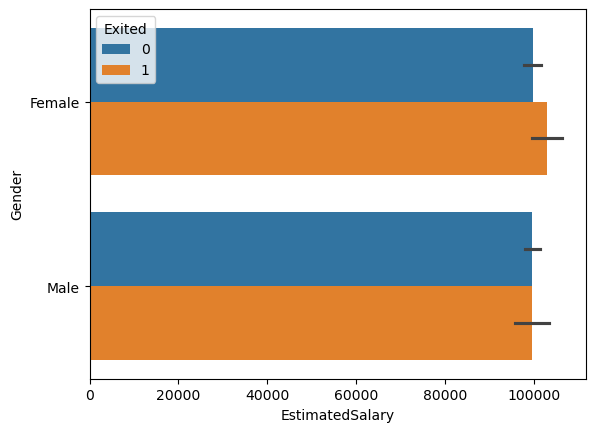

In [95]:
sns.barplot(data=df,x='EstimatedSalary',y='Gender',hue='Exited')

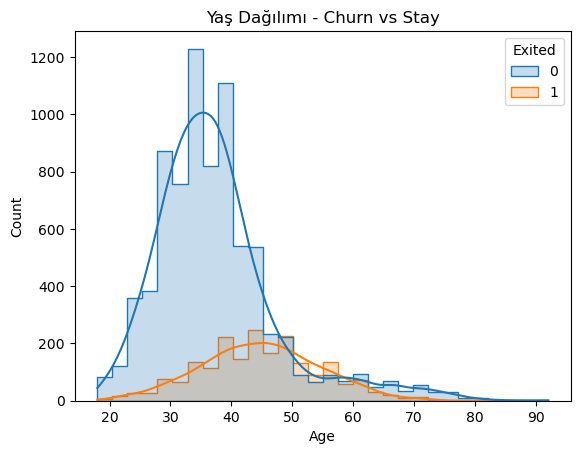

In [96]:
sns.histplot(data=df, x="Age", hue="Exited", bins=30, kde=True, element="step")
plt.title("Yaş Dağılımı - Churn vs Stay")
plt.show()

## Age ile Churn İlişkisi – Yorum

- Churn etmeyen müşteriler (0) en çok 30–40 yaş aralığında yoğunlaşmış.
- Churn eden müşteriler (1) ise 40–50 yaş bandında daha yüksek oranda görülüyor.
- Genç yaş grubunda (20–30) churn oranı düşük → gençler bankaya daha sadık.
- Yaş ilerledikçe churn riski artıyor, özellikle 40+ grupta daha belirgin.


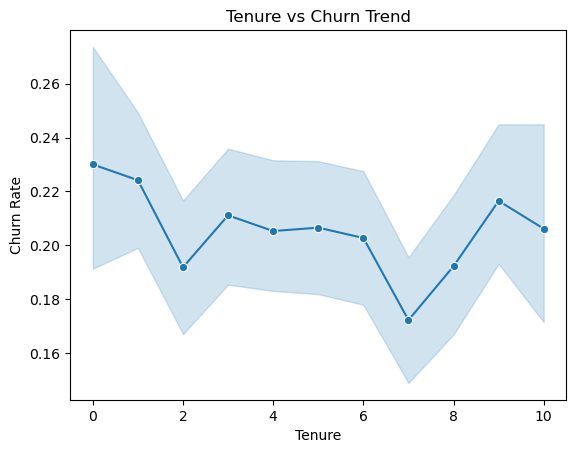

In [97]:
sns.lineplot(data=df, x="Tenure", y="Exited", marker="o")
plt.title("Tenure vs Churn Trend")
plt.ylabel("Churn Rate")
plt.show()


## Tenure vs Churn Trend Yorumu

- **0–1 yıl müşteriler:** Churn oranı yüksek (~%23–24) → yeni gelen müşteri kolay kaybediliyor.  
- **2–6 yıl müşteriler:** Churn oranı düşüyor (~%17–21) → bu dönem en sadık grup.  
- **7–10 yıl müşteriler:** Churn oranı tekrar yükseliyor (~%21–22) → uzun süreli müşterilerde risk yeniden artıyor.  

 Banka açısından:
- İlk yıl onboarding süreci güçlendirilmeli.
- 7+ yıl kalanlara özel sadakat programları geliştirilmeli.


<Axes: xlabel='NumOfProducts', ylabel='count'>

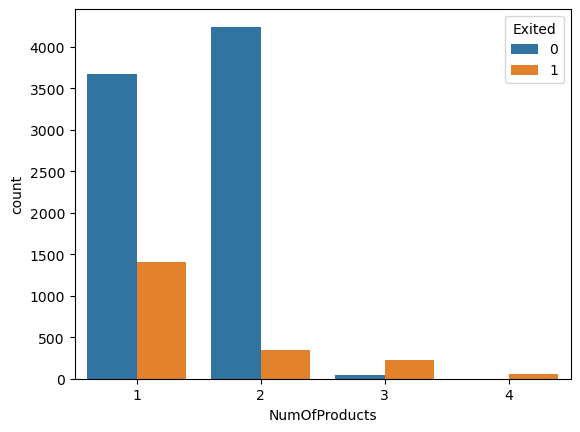

In [98]:
sns.countplot(data=df,x='NumOfProducts',hue='Exited')

## NumOfProducts vs Churn Yorumu

- **1 ürün kullananlar:** En yüksek churn riski olan grup.  
- **2 ürün kullananlar:** En sadık grup → churn oranı en düşük.  
- **3 ve 4 ürün kullananlar:** Müşteri sayısı az, ama churn oranı çok yüksek.  

 İş açısından: Banka özellikle **1 ürün kullananlara yeni ürün satmalı**
 
Ama **3+ ürün kullananlar için özel memnuniyet programları** geliştirilmeli çünkü beklentileri yüksek olabilir.


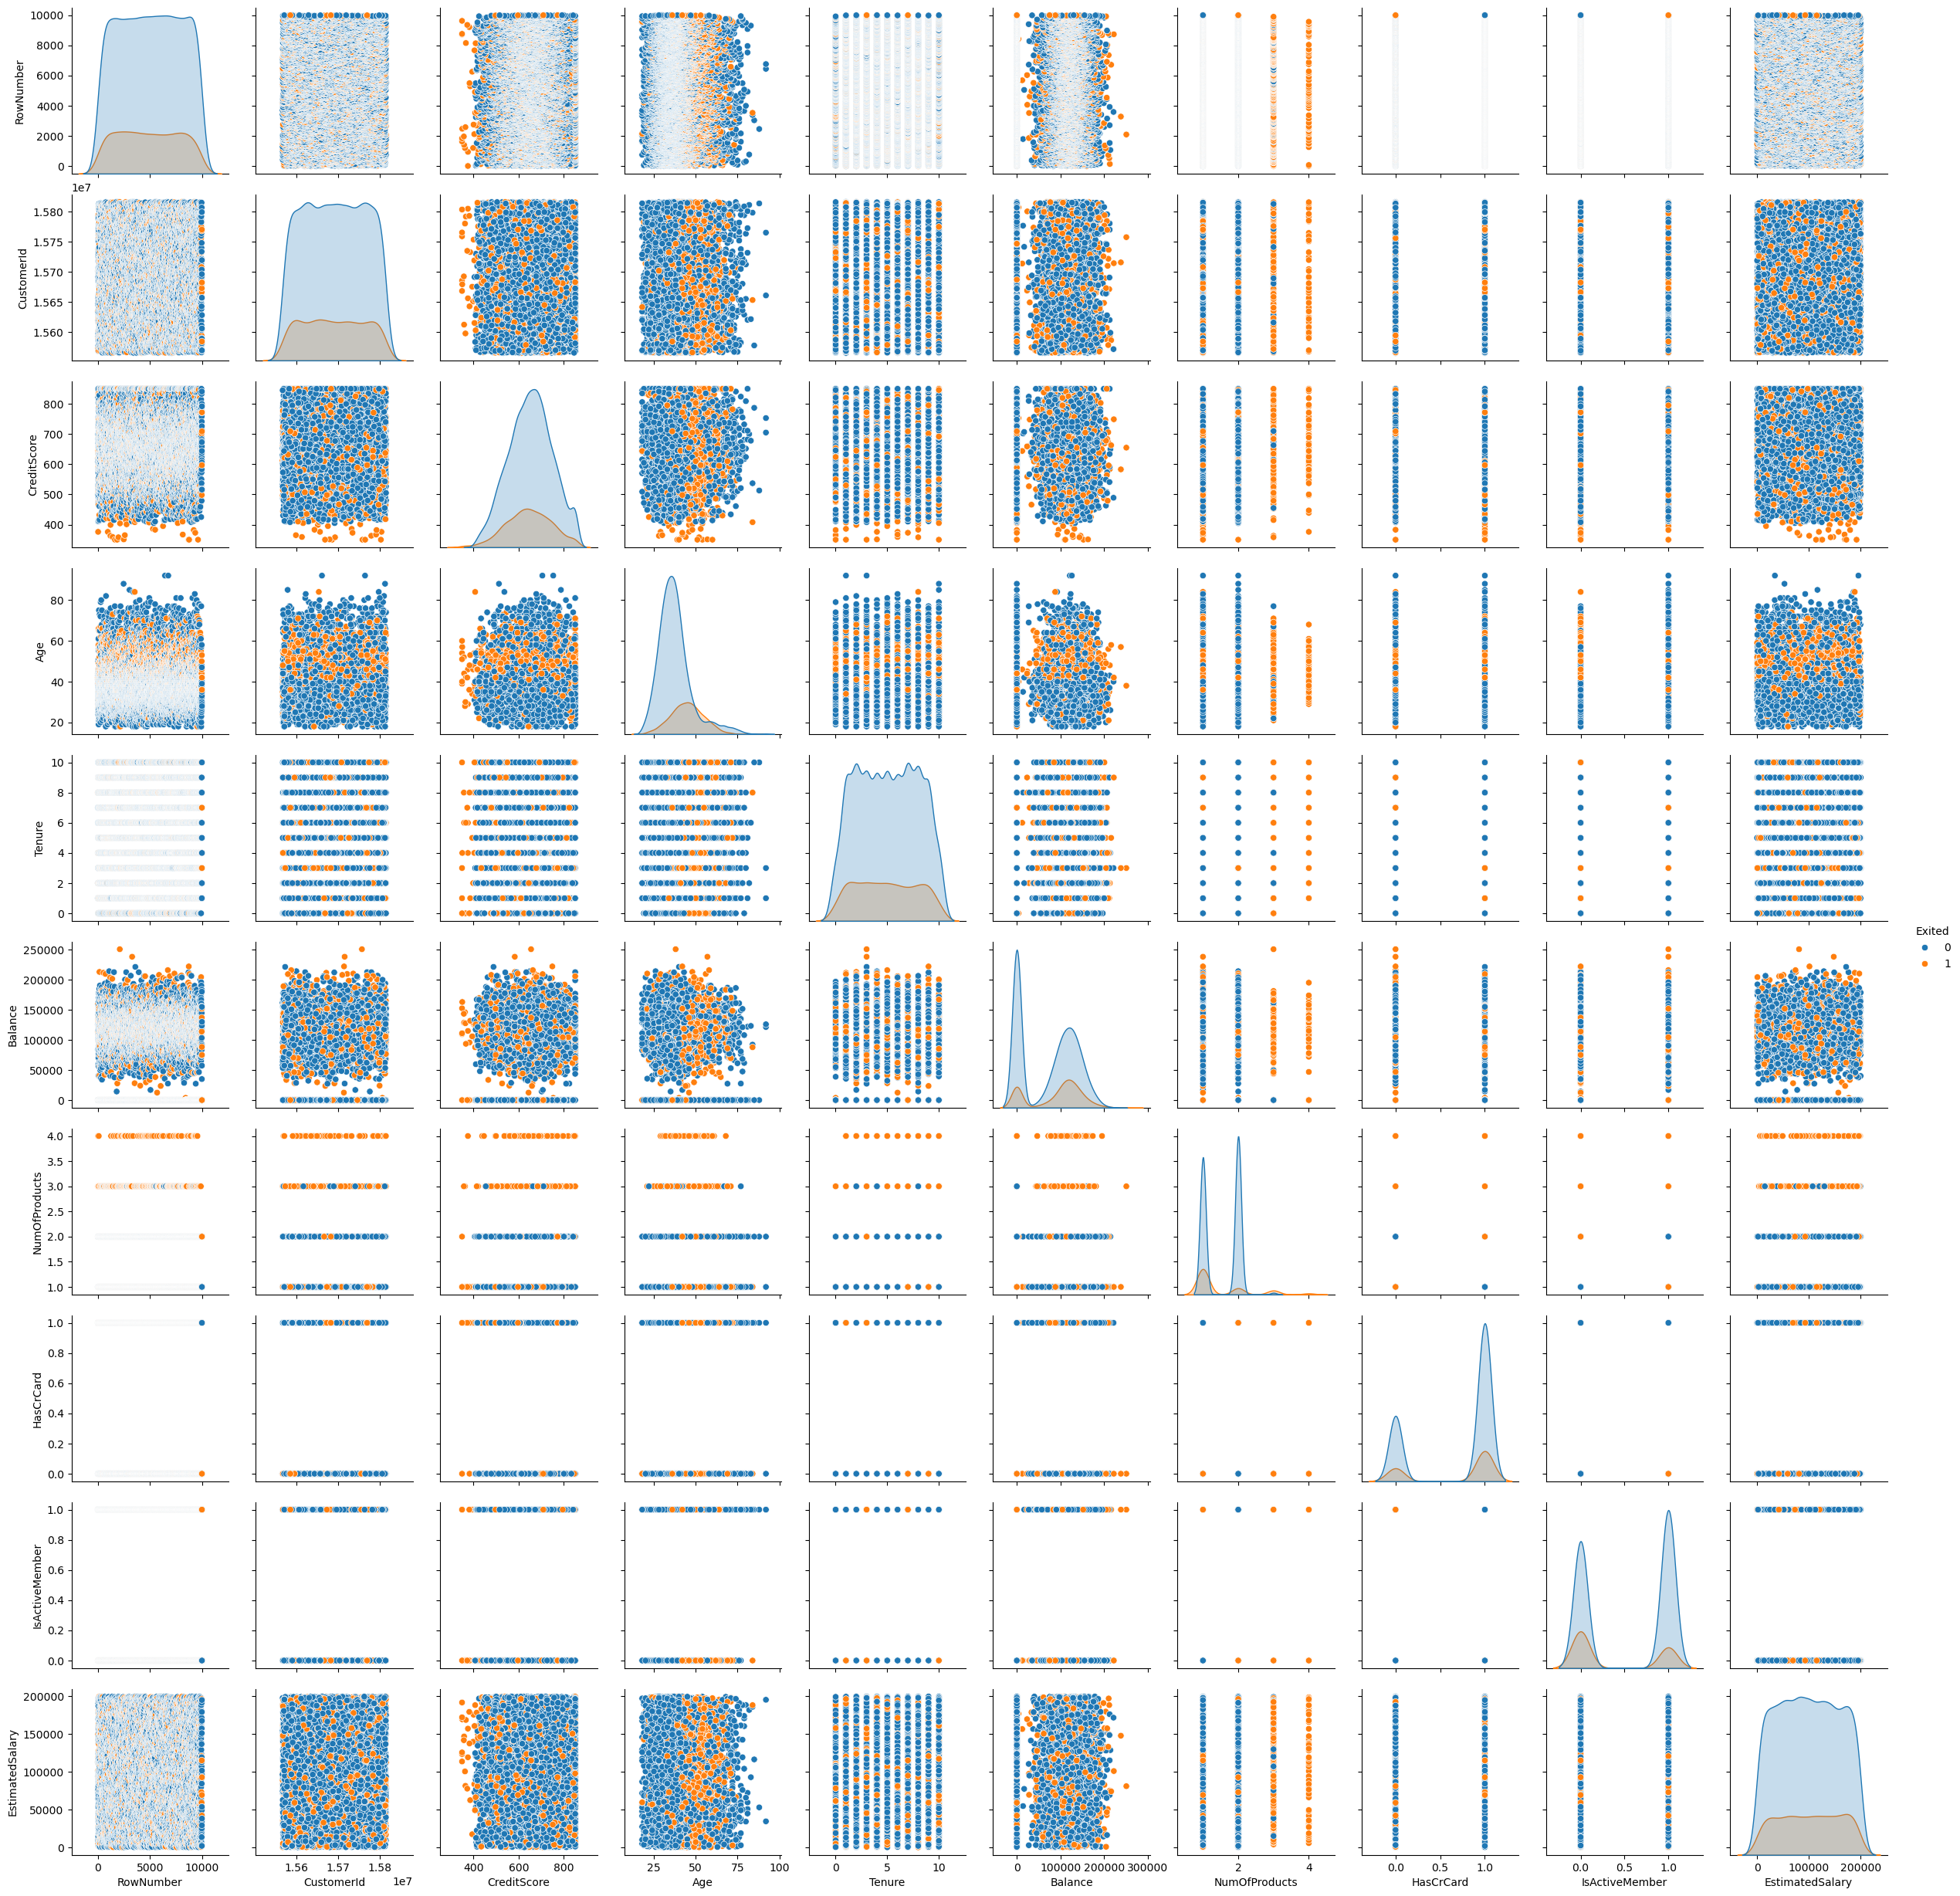

In [99]:
sns.pairplot(hue='Exited',data=df)
plt.show()

In [100]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

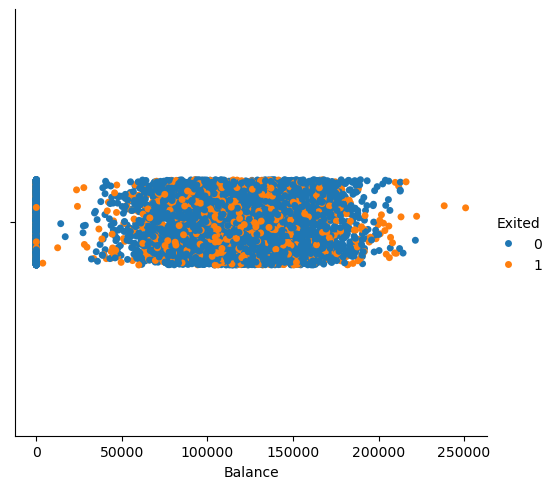

In [101]:
sns.catplot(x=df["Balance"],hue=df["Exited"])


In [102]:
df=df.drop(['RowNumber','CustomerId','Surname'],axis='columns')

In [103]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [104]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [105]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [106]:
numerical=[]
categorical=[]
for i in df.columns:
    if df[i].dtype=='O':
        categorical.append(i)
    else:
        numerical.append(i)
    

In [107]:
numerical

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [108]:
categorical

['Geography', 'Gender']

In [109]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded=encoder.fit_transform(df[['Geography']])

In [110]:
encoded = encoder.fit_transform(df["Geography"].to_frame())

In [111]:
encoded_cols = encoder.get_feature_names_out(["Geography"])
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

df_encoded = pd.concat([df.drop("Geography", axis=1), encoded_df], axis=1)

In [112]:
df_encoded

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,0.0,0.0
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,0.0,0.0
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,0.0,0.0
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,1.0,0.0


In [113]:
df['Gender_encoded']=df['Gender'].map({'Female':0,'Male':1})

In [114]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_encoded
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,1
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1


In [115]:
df = pd.concat([df.drop("Geography", axis=1), encoded_df], axis=1)


In [116]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_encoded,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,0,0.0,0.0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0,0.0,1.0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,0,0.0,0.0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0,0.0,0.0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,1,0.0,0.0
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,1,0.0,0.0
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,0,0.0,0.0
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,1,1.0,0.0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  object 
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Gender_encoded     10000 non-null  int64  
 11  Geography_Germany  10000 non-null  float64
 12  Geography_Spain    10000 non-null  float64
dtypes: float64(4), int64(8), object(1)
memory usage: 1015.8+ KB


In [118]:
X=df.drop(['Exited'],axis=1)
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)